Imports

In [53]:
# =========================
# Imports
# =========================

import sys

# Install required packages silently
!{sys.executable} -m pip install -q ipywidgets > nul 2>&1
!{sys.executable} -m pip install -q scikit-learn > nul 2>&1
!{sys.executable} -m pip install -q pandas > nul 2>&1
!{sys.executable} -m pip install -q matplotlib > nul 2>&1

import os
import random
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Subset
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from PIL import Image

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [48]:
# =========================
# Imports
# =========================

import sys
import subprocess

# Install required packages silently
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scikit-learn"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pandas"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "matplotlib"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

import os
import random
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Subset
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from PIL import Image

print("Imports completed successfully.")

Imports completed successfully.


Device + Seed

In [6]:
# =========================
# Device + Seed
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Using:", device)

Using: cuda


Dataset Path

In [7]:
DATA_DIR = r"C:\Users\Admin\Desktop\SkinColab"

Transforms

In [8]:
# =========================
# Transforms
# =========================

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

Dataset + Split

In [9]:
# =========================
# Dataset + Split
# =========================

# Important:
# We create separate datasets for train/val/test to avoid transform conflict.
# This prevents validation/test transform from overwriting train augmentation.

full_dataset = datasets.ImageFolder(DATA_DIR)

train_dataset_full = datasets.ImageFolder(DATA_DIR, transform=train_transform)
val_dataset_full = datasets.ImageFolder(DATA_DIR, transform=test_transform)
test_dataset_full = datasets.ImageFolder(DATA_DIR, transform=test_transform)

num_classes = len(full_dataset.classes)
class_names = full_dataset.classes

train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

indices = list(range(len(full_dataset)))

train_indices, val_indices, test_indices = random_split(
    indices,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_ds = Subset(train_dataset_full, train_indices.indices)
val_ds = Subset(val_dataset_full, val_indices.indices)
test_ds = Subset(test_dataset_full, test_indices.indices)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Train size:", len(train_ds))
print("Validation size:", len(val_ds))
print("Test size:", len(test_ds))

Classes: ['Acne', 'Eczema', 'Fungal infection', 'Melanoma', 'Psoriasis', 'Viral infection']
Number of classes: 6
Train size: 19314
Validation size: 2414
Test size: 2415


Class Distribution:
              Class  Number of Images
0              Acne              3541
1            Eczema              4343
2  Fungal infection              4359
3          Melanoma              3719
4         Psoriasis              4720
5   Viral infection              3461


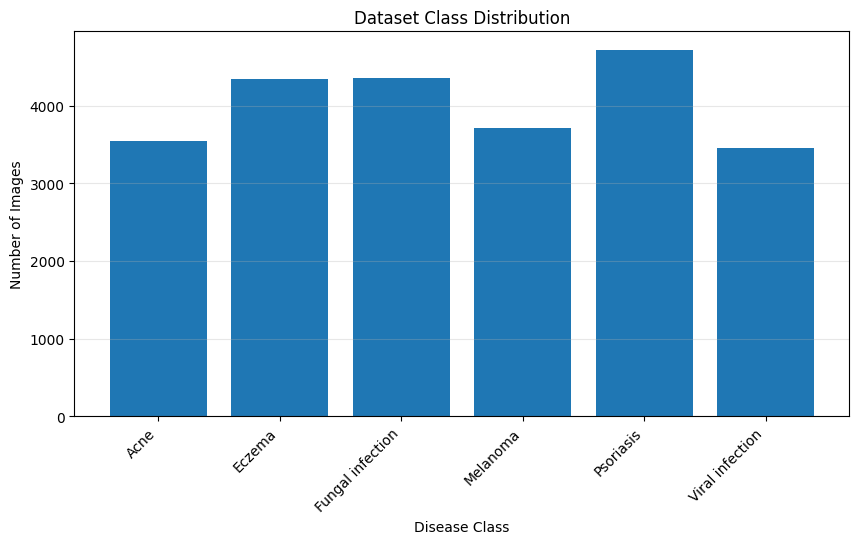

In [10]:
# =========================
# Class Distribution Array + Graph
# =========================

all_labels = np.array(full_dataset.targets)

class_counts = np.bincount(all_labels, minlength=num_classes)

class_distribution_df = pd.DataFrame({
    "Class": class_names,
    "Number of Images": class_counts
})

print("Class Distribution:")
print(class_distribution_df)

plt.figure(figsize=(10, 5))
plt.bar(class_names, class_counts)
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.title("Dataset Class Distribution")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.savefig("class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

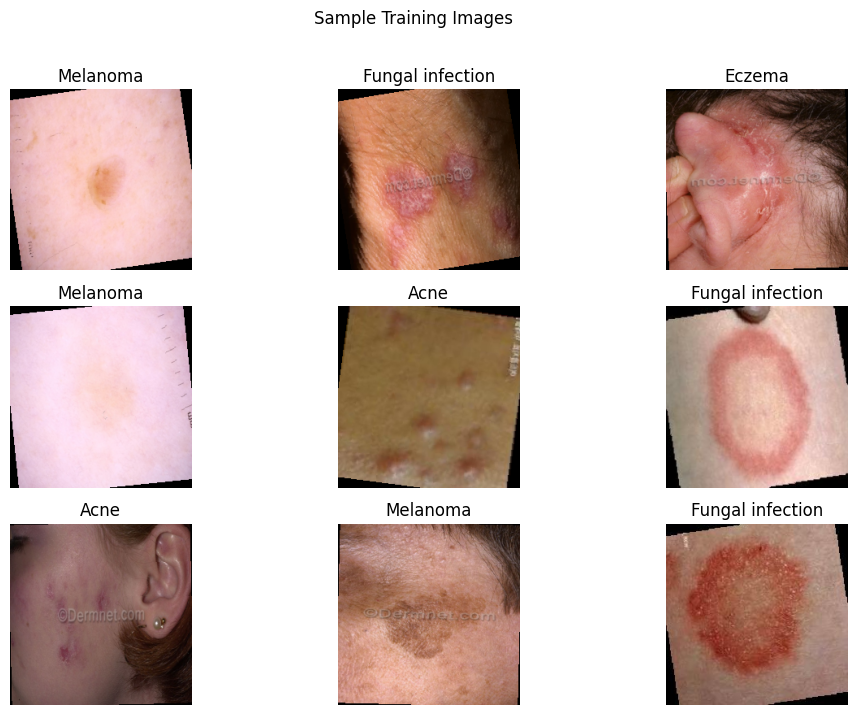

In [11]:
# =========================
# Sample Images Grid
# =========================

def denormalize_image(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    image = tensor.cpu() * std + mean
    image = image.clamp(0, 1)

    return image.permute(1, 2, 0).numpy()


plt.figure(figsize=(12, 8))

for i in range(min(9, len(train_ds))):
    image, label = train_ds[i]

    plt.subplot(3, 3, i + 1)
    plt.imshow(denormalize_image(image))
    plt.title(class_names[label])
    plt.axis("off")

plt.suptitle("Sample Training Images")
plt.savefig("sample_training_images.png", dpi=300, bbox_inches="tight")
plt.show()

Class Weights

In [12]:
# =========================
# Class Weights
# =========================

train_labels = [full_dataset.targets[i] for i in train_indices.indices]

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(weights, dtype=torch.float).to(device)

class_weights_df = pd.DataFrame({
    "Class": class_names,
    "Weight": weights
})

print("Class Weights:")
print(class_weights_df)

Class Weights:
              Class    Weight
0              Acne  1.121212
1            Eczema  0.929004
2  Fungal infection  0.931424
3          Melanoma  1.079839
4         Psoriasis  0.848445
5   Viral infection  1.171824


DataLoaders

In [13]:
# =========================
# DataLoaders
# =========================

# num_workers=0 is safer for Windows/Jupyter.
# If you run on Linux or Colab, you can change it to 2 or 4.

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Model

In [36]:
# =========================
# Model
# =========================

model = models.efficientnet_b0(weights="IMAGENET1K_V1")

# Freeze most layers
for param in list(model.parameters())[:-20]:
    param.requires_grad = False

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)

model = model.to(device)



Loss & Optimizer

In [15]:
# =========================
# Loss & Optimizer
# =========================

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Training +  Validation

In [16]:
# =========================
# Training + Validation
# =========================

EPOCHS = 10

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_acc = 0.0

for epoch in range(EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        preds = outputs.argmax(1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss / train_total
    train_acc = train_correct / train_total

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            preds = outputs.argmax(1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    # Save best model based on validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_skin_model.pth")
        print("Best model saved.")

Epoch 1/10 | Train Loss: 0.9377 | Train Acc: 0.6512 | Val Loss: 0.6049 | Val Acc: 0.7838
Best model saved.
Epoch 2/10 | Train Loss: 0.6240 | Train Acc: 0.7597 | Val Loss: 0.5047 | Val Acc: 0.8227
Best model saved.
Epoch 3/10 | Train Loss: 0.5328 | Train Acc: 0.7980 | Val Loss: 0.4490 | Val Acc: 0.8409
Best model saved.
Epoch 4/10 | Train Loss: 0.4650 | Train Acc: 0.8286 | Val Loss: 0.4045 | Val Acc: 0.8641
Best model saved.
Epoch 5/10 | Train Loss: 0.4290 | Train Acc: 0.8413 | Val Loss: 0.3711 | Val Acc: 0.8728
Best model saved.
Epoch 6/10 | Train Loss: 0.3767 | Train Acc: 0.8625 | Val Loss: 0.3531 | Val Acc: 0.8807
Best model saved.
Epoch 7/10 | Train Loss: 0.3411 | Train Acc: 0.8728 | Val Loss: 0.3291 | Val Acc: 0.8902
Best model saved.
Epoch 8/10 | Train Loss: 0.3108 | Train Acc: 0.8891 | Val Loss: 0.3048 | Val Acc: 0.9035
Best model saved.
Epoch 9/10 | Train Loss: 0.2833 | Train Acc: 0.8974 | Val Loss: 0.2879 | Val Acc: 0.9105
Best model saved.
Epoch 10/10 | Train Loss: 0.2638 | Tr

In [17]:
# =========================
# Training History Arrays
# =========================

history_df = pd.DataFrame(history)

print("Training History:")
print(history_df)

history_df.to_csv("training_history.csv", index=False)

Training History:
   train_loss  val_loss  train_acc   val_acc
0    0.937659  0.604851   0.651186  0.783761
1    0.623966  0.504739   0.759708  0.822701
2    0.532770  0.448966   0.797970  0.840928
3    0.464979  0.404463   0.828622  0.864126
4    0.429014  0.371061   0.841255  0.872825
5    0.376659  0.353051   0.862483  0.880696
6    0.341092  0.329102   0.872838  0.890224
7    0.310757  0.304769   0.889148  0.903480
8    0.283340  0.287886   0.897380  0.910522
9    0.263764  0.267880   0.904991  0.922121


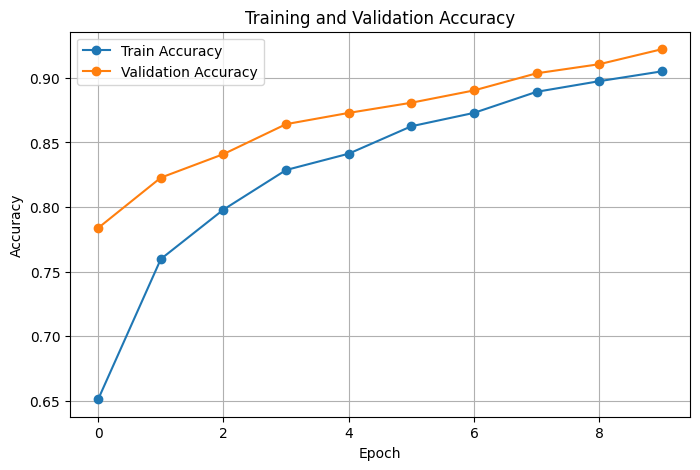

In [18]:
# =========================
# Training Accuracy Graph
# =========================

plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(history["val_acc"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

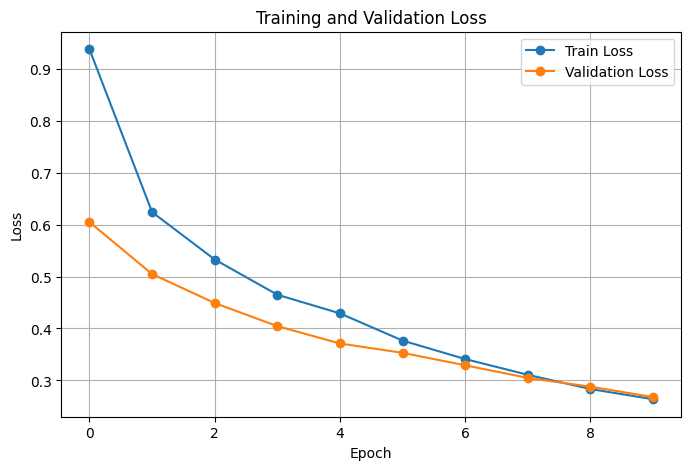

In [19]:
# =========================
# Training Loss Graph
# =========================

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], marker="o", label="Train Loss")
plt.plot(history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig("loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

Save Model

In [20]:
# =========================
# Save Model
# =========================

torch.save(model.state_dict(), "skin_model.pth")

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Final model saved as skin_model.pth")
print("Class names saved as class_names.json")

Final model saved as skin_model.pth
Class names saved as class_names.json


Test

In [21]:
# =========================
# Test
# =========================

# Load the best model before testing
model.load_state_dict(torch.load("best_skin_model.pth", map_location=device))
model.eval()

y_true = []
y_pred = []
y_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        preds = outputs.argmax(1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(labels.numpy())
        y_probs.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

test_accuracy = accuracy_score(y_true, y_pred)

print("Test Accuracy:", test_accuracy)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

Test Accuracy: 0.901863354037267
                  precision    recall  f1-score   support

            Acne     0.9210    0.9410    0.9309       322
          Eczema     0.8991    0.8615    0.8799       455
Fungal infection     0.9884    0.9323    0.9596       458
        Melanoma     0.9666    0.9586    0.9626       362
       Psoriasis     0.8366    0.8571    0.8467       448
 Viral infection     0.8125    0.8784    0.8442       370

        accuracy                         0.9019      2415
       macro avg     0.9040    0.9048    0.9040      2415
    weighted avg     0.9042    0.9019    0.9026      2415



In [22]:
# =========================
# Save Test Results Arrays
# =========================

test_results_df = pd.DataFrame({
    "True Label Index": y_true,
    "Predicted Label Index": y_pred,
    "True Class": [class_names[i] for i in y_true],
    "Predicted Class": [class_names[i] for i in y_pred]
})

for i, class_name in enumerate(class_names):
    test_results_df[f"Probability_{class_name}"] = y_probs[:, i]

print("Test Results Array:")
print(test_results_df.head())

test_results_df.to_csv("test_predictions.csv", index=False)

Test Results Array:
   True Label Index  Predicted Label Index        True Class  \
0                 3                      3          Melanoma   
1                 1                      1            Eczema   
2                 5                      5   Viral infection   
3                 2                      2  Fungal infection   
4                 5                      1   Viral infection   

    Predicted Class  Probability_Acne  Probability_Eczema  \
0          Melanoma      1.260140e-10        3.987466e-11   
1            Eczema      4.191828e-07        9.976574e-01   
2   Viral infection      4.375967e-03        1.354695e-03   
3  Fungal infection      1.755978e-04        5.094955e-07   
4            Eczema      1.763901e-01        4.176292e-01   

   Probability_Fungal infection  Probability_Melanoma  Probability_Psoriasis  \
0                  3.124696e-12          1.000000e+00           6.221762e-10   
1                  6.472802e-05          5.064338e-08           2.27

In [23]:
# =========================
# Save Classification Report
# =========================

with open("classification_report.txt", "w") as f:
    f.write(f"Test Accuracy: {test_accuracy:.4f}\n\n")
    f.write(report)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv("classification_report.csv", index=True)

print("Classification report saved as classification_report.txt and classification_report.csv")

Classification report saved as classification_report.txt and classification_report.csv


In [24]:
# =========================
# Confusion Matrix Array
# =========================

cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

print("Confusion Matrix Array:")
print(cm_df)

cm_df.to_csv("confusion_matrix_array.csv")

Confusion Matrix Array:
                  Acne  Eczema  Fungal infection  Melanoma  Psoriasis  \
Acne               303       3                 0         2          3   
Eczema               7     392                 2         0         34   
Fungal infection     0       4               427         1         21   
Melanoma             4       0                 1       347          3   
Psoriasis            6      17                 2         7        384   
Viral infection      9      20                 0         2         14   

                  Viral infection  
Acne                           11  
Eczema                         20  
Fungal infection                5  
Melanoma                        7  
Psoriasis                      32  
Viral infection               325  


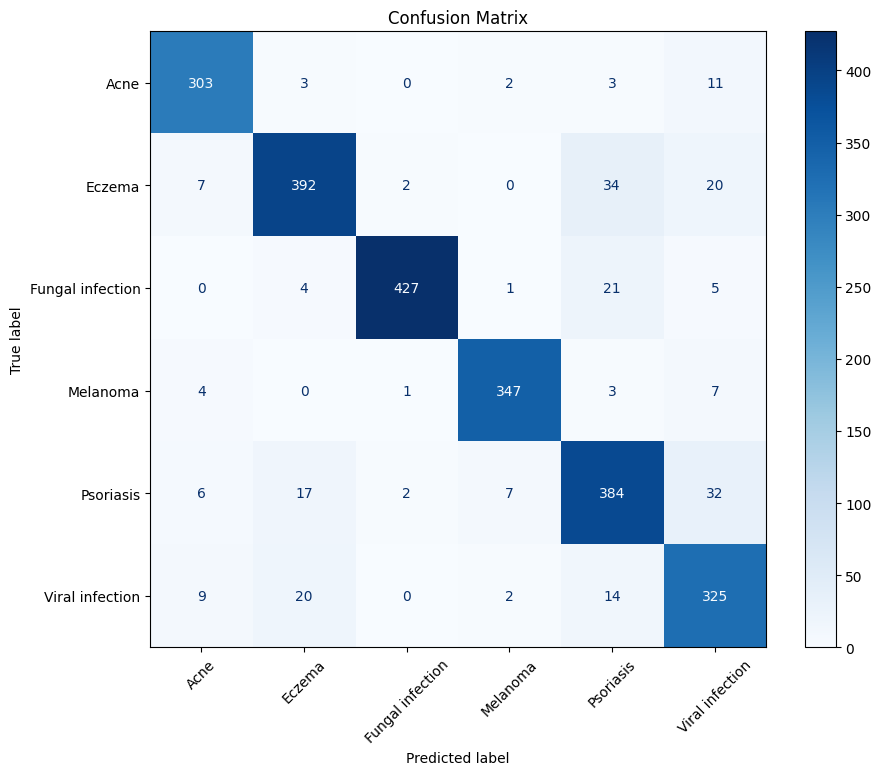

In [25]:
# =========================
# Confusion Matrix Heatmap
# =========================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45
)

plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
# =========================
# Normalized Confusion Matrix Array
# =========================

cm_normalized = confusion_matrix(y_true, y_pred, normalize="true")

cm_normalized_df = pd.DataFrame(
    cm_normalized,
    index=class_names,
    columns=class_names
)

print("Normalized Confusion Matrix Array:")
print(cm_normalized_df)

cm_normalized_df.to_csv("normalized_confusion_matrix_array.csv")

Normalized Confusion Matrix Array:
                      Acne    Eczema  Fungal infection  Melanoma  Psoriasis  \
Acne              0.940994  0.009317          0.000000  0.006211   0.009317   
Eczema            0.015385  0.861538          0.004396  0.000000   0.074725   
Fungal infection  0.000000  0.008734          0.932314  0.002183   0.045852   
Melanoma          0.011050  0.000000          0.002762  0.958564   0.008287   
Psoriasis         0.013393  0.037946          0.004464  0.015625   0.857143   
Viral infection   0.024324  0.054054          0.000000  0.005405   0.037838   

                  Viral infection  
Acne                     0.034161  
Eczema                   0.043956  
Fungal infection         0.010917  
Melanoma                 0.019337  
Psoriasis                0.071429  
Viral infection          0.878378  


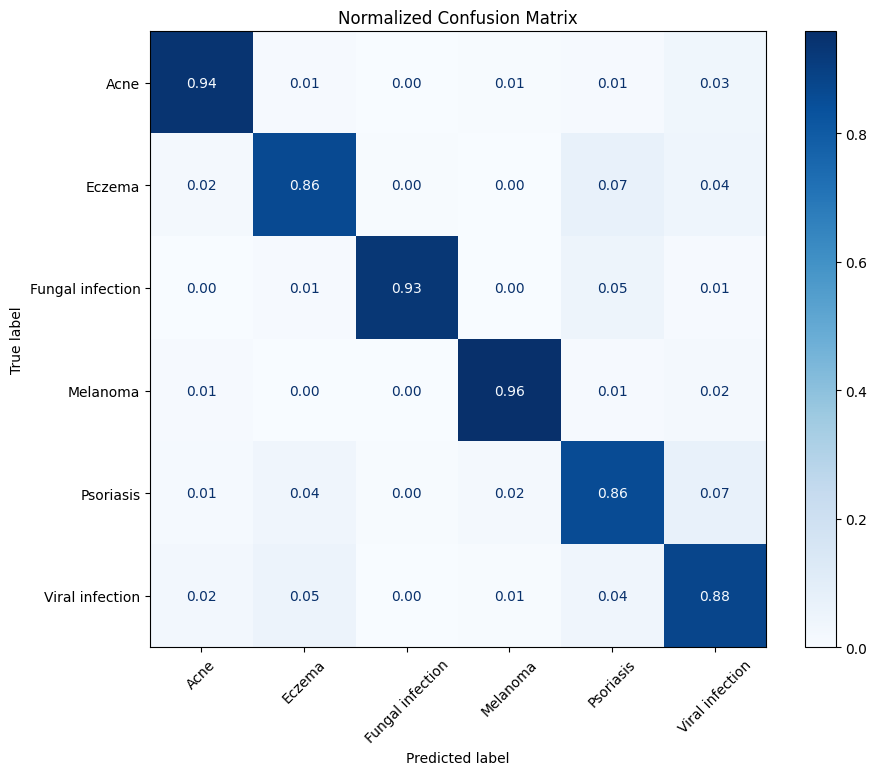

In [27]:
# =========================
# Normalized Confusion Matrix Heatmap
# =========================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(
    ax=ax,
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=45
)

plt.title("Normalized Confusion Matrix")
plt.savefig("normalized_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

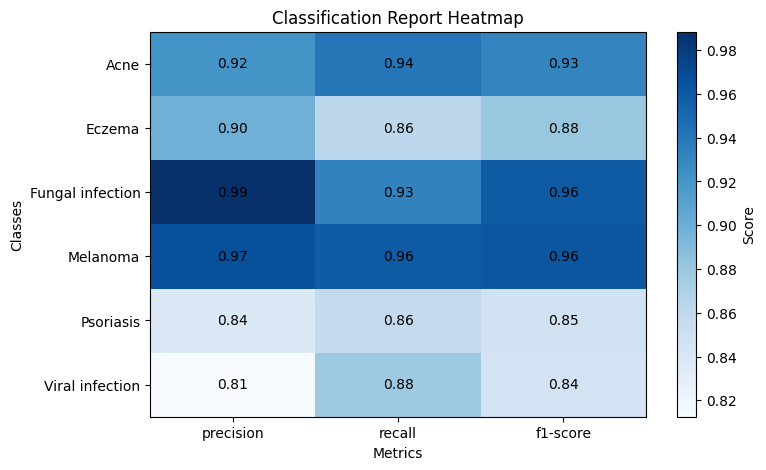

In [28]:
# =========================
# Classification Report Heatmap
# =========================

metrics_df = report_df.iloc[:num_classes][["precision", "recall", "f1-score"]]

plt.figure(figsize=(8, 5))
plt.imshow(metrics_df.values, aspect="auto", cmap="Blues")
plt.colorbar(label="Score")

plt.xticks(
    ticks=np.arange(len(metrics_df.columns)),
    labels=metrics_df.columns
)

plt.yticks(
    ticks=np.arange(len(metrics_df.index)),
    labels=metrics_df.index
)

for i in range(metrics_df.shape[0]):
    for j in range(metrics_df.shape[1]):
        plt.text(
            j,
            i,
            f"{metrics_df.values[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Classification Report Heatmap")
plt.xlabel("Metrics")
plt.ylabel("Classes")
plt.savefig("classification_report_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

Per-Class Accuracy:
              Class  Accuracy
0              Acne  0.940994
1            Eczema  0.861538
2  Fungal infection  0.932314
3          Melanoma  0.958564
4         Psoriasis  0.857143
5   Viral infection  0.878378


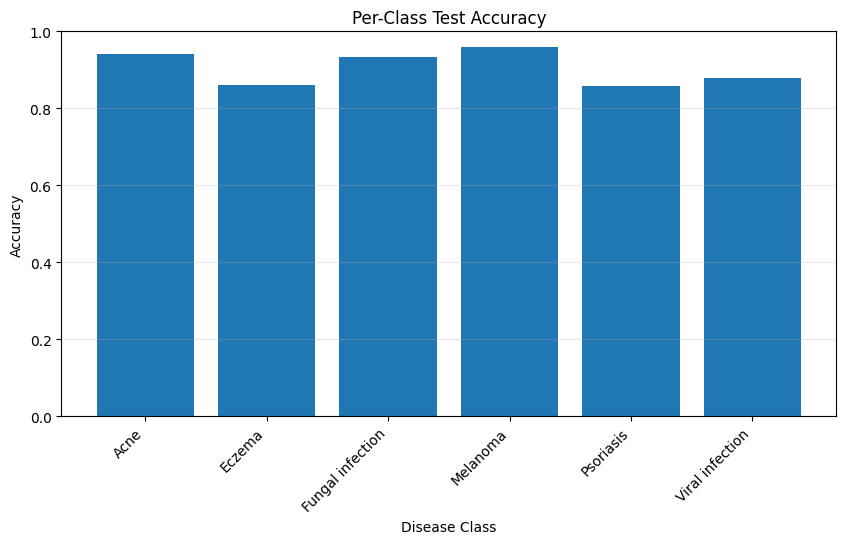

In [29]:
# =========================
# Per-Class Accuracy Graph
# =========================

per_class_correct = np.diag(cm)
per_class_total = cm.sum(axis=1)

per_class_accuracy = per_class_correct / np.maximum(per_class_total, 1)

per_class_accuracy_df = pd.DataFrame({
    "Class": class_names,
    "Accuracy": per_class_accuracy
})

print("Per-Class Accuracy:")
print(per_class_accuracy_df)

per_class_accuracy_df.to_csv("per_class_accuracy.csv", index=False)

plt.figure(figsize=(10, 5))
plt.bar(class_names, per_class_accuracy)
plt.xlabel("Disease Class")
plt.ylabel("Accuracy")
plt.title("Per-Class Test Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.savefig("per_class_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

Disease Info

In [30]:
# =========================
# Disease Info
# =========================

DISEASE_INFO = {
    "Acne": {
        "causes": [
            "Hormonal changes",
            "Excess oil production",
            "Bacteria (Cutibacterium acnes)",
            "Clogged pores"
        ],
    },

    "Eczema": {
        "causes": [
            "Genetic predisposition",
            "Allergic reactions",
            "Dry skin",
            "Immune system dysfunction"
        ],
    },

    "Psoriasis": {
        "causes": [
            "Autoimmune disorder",
            "Genetics",
            "Stress triggers",
            "Infections"
        ],
    },

    "Melanoma": {
        "causes": [
            "UV radiation exposure",
            "Genetic mutations",
            "Fair skin risk"
        ],
    },

    "Fungal infection": {
        "causes": [
            "Moist environment",
            "Poor hygiene",
            "Contagious contact",
            "Weak immune system"
        ],
    },

    "Viral infection": {
        "causes": [
            "Virus exposure",
            "Direct contact",
            "Weak immune system"
        ],
    }
}

Functions

In [31]:
def infer_cause(disease, answers):
    # Safe access
    info = DISEASE_INFO.get(disease, None)
    if info is None:
        return "Unknown"

    scores = {c: 0 for c in info["causes"]}

    # 🔹 General signals (apply to ALL diseases)
    if answers.get("itching") == "Yes":
        for c in scores:
            scores[c] += 0.5

    if answers.get("pain") == "Yes":
        for c in scores:
            scores[c] += 0.5

    if answers.get("spread") == "Yes":
        for c in scores:
            scores[c] += 1

    # 🔹 Disease-specific logic

    # Eczema
    if disease == "Eczema":
        if answers.get("chemical_exposure") == "Yes":
            scores["Allergic reactions"] += 2
        if answers.get("family_history") == "Yes":
            scores["Genetic predisposition"] += 2

    # Fungal infection
    elif disease == "Fungal infection":
        if answers.get("moist") == "Yes":
            scores["Moist environment"] += 3
        if answers.get("spread") == "Yes":
            scores["Contagious contact"] += 2

    # Melanoma
    elif disease == "Melanoma":
        if answers.get("sun_exposure") == "Yes":
            scores["UV radiation exposure"] += 3

    # Acne
    elif disease == "Acne":
        if answers.get("chemical_exposure") == "Yes":
            scores["Clogged pores"] += 2
        if answers.get("pain") == "Yes":
            scores["Bacteria (Cutibacterium acnes)"] += 1

    # Psoriasis
    elif disease == "Psoriasis":
        if answers.get("family_history") == "Yes":
            scores["Genetics"] += 2

    # Viral infection
    elif disease == "Viral infection":
        if answers.get("spread") == "Yes":
            scores["Direct contact"] += 2

    # 🔹 Return best cause
    return max(scores, key=scores.get)






In [32]:
# =========================
# Questions
# =========================

QUESTIONS = {
    "itching": ("Is the area itchy?", ["Yes", "No"]),
    "pain": ("Is there pain?", ["Yes", "No"]),
    "spread": ("Is it spreading?", ["Yes", "No"]),
    "moist": ("Is the area moist/sweaty?", ["Yes", "No"]),
    "family_history": ("Do you have family history?", ["Yes", "No"]),
    "chemical_exposure": ("Any new skincare or chemicals used?", ["Yes", "No"]),
    "sun_exposure": ("High sun exposure recently?", ["Yes", "No"])
}

DISEASE_QUESTIONS = {
    "Acne": ["pain", "chemical_exposure"],
    "Eczema": ["itching", "chemical_exposure", "family_history"],
    "Psoriasis": ["family_history", "itching"],
    "Melanoma": ["sun_exposure"],
    "Fungal infection": ["moist", "spread", "itching"],
    "Viral infection": ["spread", "pain"]
}

Prediction Function

In [33]:
# =========================
# Functions
# =========================

def infer_cause(disease, answers):
    info = DISEASE_INFO.get(disease, None)

    if info is None:
        return "Unknown"

    scores = {c: 0 for c in info["causes"]}

    # General signals
    if answers.get("itching") == "Yes":
        for c in scores:
            scores[c] += 0.5

    if answers.get("pain") == "Yes":
        for c in scores:
            scores[c] += 0.5

    if answers.get("spread") == "Yes":
        for c in scores:
            scores[c] += 1

    # Disease-specific logic
    if disease == "Eczema":
        if answers.get("chemical_exposure") == "Yes":
            scores["Allergic reactions"] += 2

        if answers.get("family_history") == "Yes":
            scores["Genetic predisposition"] += 2

    elif disease == "Fungal infection":
        if answers.get("moist") == "Yes":
            scores["Moist environment"] += 3

        if answers.get("spread") == "Yes":
            scores["Contagious contact"] += 2

    elif disease == "Melanoma":
        if answers.get("sun_exposure") == "Yes":
            scores["UV radiation exposure"] += 3

    elif disease == "Acne":
        if answers.get("chemical_exposure") == "Yes":
            scores["Clogged pores"] += 2

        if answers.get("pain") == "Yes":
            scores["Bacteria (Cutibacterium acnes)"] += 1

    elif disease == "Psoriasis":
        if answers.get("family_history") == "Yes":
            scores["Genetics"] += 2

    elif disease == "Viral infection":
        if answers.get("spread") == "Yes":
            scores["Direct contact"] += 2

    best_cause = max(scores, key=scores.get)

    return best_cause

In [34]:
# =========================
# Prediction Function
# =========================

def predict_with_questions(image_path):
    image_original = Image.open(image_path).convert("RGB")

    image = test_transform(image_original).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        outputs = model(image)
        probs = torch.softmax(outputs, dim=1)
        confidence, pred = torch.max(probs, 1)

    disease = class_names[pred.item()].strip()
    confidence = confidence.item()

    probabilities = probs.cpu().numpy()[0]

    # Show uploaded image
    plt.figure(figsize=(5, 5))
    plt.imshow(image_original)
    plt.title("Input Skin Image")
    plt.axis("off")
    plt.show()

    # Show prediction probabilities
    plt.figure(figsize=(10, 5))
    plt.bar(class_names, probabilities)
    plt.xlabel("Disease Class")
    plt.ylabel("Probability")
    plt.title("Prediction Probability for Each Class")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)
    plt.savefig("single_prediction_probabilities.png", dpi=300, bbox_inches="tight")
    plt.show()

    if disease not in DISEASE_INFO:
        print(f"Warning: {disease} not found in DISEASE_INFO")
        info = {"causes": ["Unknown"]}
    else:
        info = DISEASE_INFO[disease]

    answers = {}

    print("\n===== Answer the following questions =====\n")

    for q in DISEASE_QUESTIONS.get(disease, []):
        text, options = QUESTIONS[q]

        print(f"\n{text}")
        print("1. Yes")
        print("2. No")

        while True:
            choice = input("Enter 1 or 2: ").strip()

            if choice == "1":
                answers[q] = "Yes"
                break

            elif choice == "2":
                answers[q] = "No"
                break

            else:
                print("Invalid input. Please enter 1 or 2.")

    best_cause = infer_cause(disease, answers)

    print("\n===== FINAL RESULT =====")
    print(f"Disease: {disease}")
    print(f"Confidence: {confidence:.2f}")

    print("\nMost likely cause:")
    print(f"- {best_cause}")

    print("\nOther possible causes:")
    for c in info["causes"]:
        print(f"- {c}")

    print("\nMedical Disclaimer:")
    print("This is a preliminary result for awareness only. Please consult a doctor.")

    result = {
        "disease": disease,
        "confidence": confidence,
        "most_likely_cause": best_cause,
        "answers": answers,
        "probabilities": {
            class_names[i]: float(probabilities[i]) for i in range(len(class_names))
        }
    }

    return result

Run Prediction 

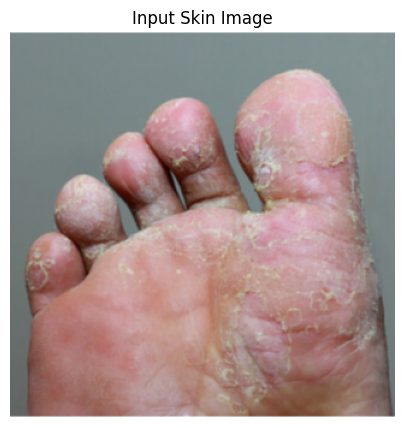

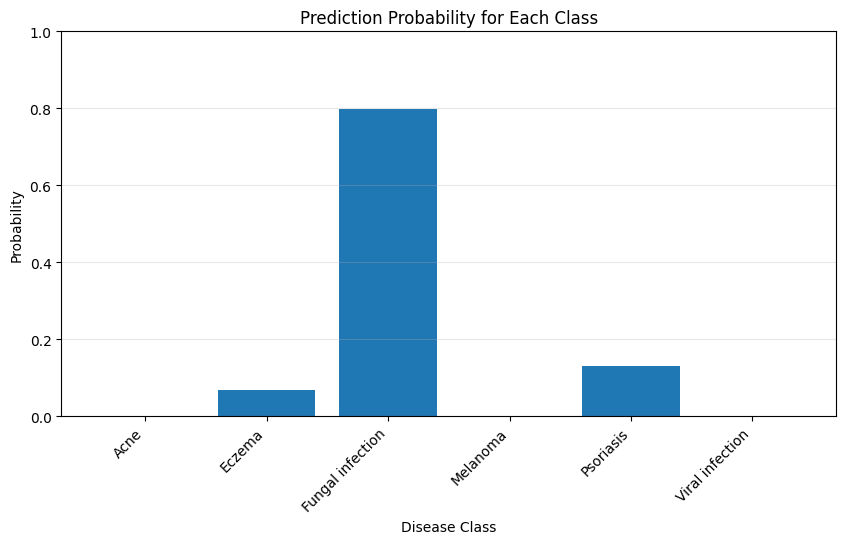


===== Answer the following questions =====


Is the area moist/sweaty?
1. Yes
2. No

Is it spreading?
1. Yes
2. No

Is the area itchy?
1. Yes
2. No

===== FINAL RESULT =====
Disease: Fungal infection
Confidence: 0.80

Most likely cause:
- Contagious contact

Other possible causes:
- Moist environment
- Poor hygiene
- Contagious contact
- Weak immune system

Medical Disclaimer:
This is a preliminary result for awareness only. Please consult a doctor.

Prediction Result Dictionary:
{'disease': 'Fungal infection', 'confidence': 0.7994300127029419, 'most_likely_cause': 'Contagious contact', 'answers': {'moist': 'No', 'spread': 'Yes', 'itching': 'Yes'}, 'probabilities': {'Acne': 3.2768541132099926e-05, 'Eczema': 0.06832744181156158, 'Fungal infection': 0.7994300127029419, 'Melanoma': 0.00030274331220425665, 'Psoriasis': 0.1308545023202896, 'Viral infection': 0.0010524842655286193}}


In [35]:
# =========================
# Run Prediction
# =========================

# Use your image path here
result = predict_with_questions("Fi.jpg")

print("\nPrediction Result Dictionary:")
print(result)